# Spot Telluride Workshop Dataset — exploration

What is in [`lorinachey/spot-telluride-workshop-dataset`](https://huggingface.co/datasets/lorinachey/spot-telluride-workshop-dataset),
and how it maps onto this repo's JEPA transition format (`TASKS.md` T12).

The dataset is a single ~83 s classroom demo run (`run1`) recorded on a
Boston Dynamics **Spot D02**, extracted from ROS bags. Nine configs:

| Config | Content | Rows | Rate |
| --- | --- | --- | --- |
| `rgb_d455` | Intel RealSense D455 color, 640×480 RGB + intrinsics | 2478 | ~30 Hz |
| `depth_d455` | D455 depth, 640×480 uint16 (mm), aligned to color | 2478 | ~30 Hz |
| `rgb_spot_frontleft` | Spot front-left cam, 640×480 **grayscale**, rotated ~90° | 742 | ~9 Hz |
| `rgb_spot_frontright` | Spot front-right cam, same | 742 | ~9 Hz |
| `pointclouds` | Ouster lidar, ASCII PCD (x y z), 65k points each | 21 | sparse bursts |
| `occupancy_grid` | 2D occupancy map snapshots, 187×85 PNG | 828 | ~10 Hz |
| `octomap` | OctoMap `.bt` binary snapshots (3D voxel map) | 911 | ~11 Hz |
| `odometry_lio_sam` | LIO-SAM SLAM pose (x y z + quaternion) | 496 | ~6 Hz |
| `odometry_imu` | IMU-preintegration pose, same schema | 41360 | ~500 Hz |

Two gotchas found while exploring, both handled below:

- Streams are **not time-synchronized** — different sensors, different rates.
  The only join key is `timestamp_ns` (approximate alignment).
- **Rows are not stored in time order** (parquet shard order splits the run
  into two blocks — the files start with the *end* of the run), and row order
  differs between configs: after time-sorting, `rgb_d455`/`depth_d455` rows
  align to < 1 ms median, but by raw row index they are off by a frame to 67 s.
  Everything below sorts by `timestamp_ns` first.

**What our pipeline needs** is `images/ + transitions_gt.csv` with one-hot
actions `(forward, stop, left, right)` — and this dataset has **no action
labels**. The last section derives pseudo-actions from odometry as a preview
of the T12 converter.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from huggingface_hub import hf_hub_download

REPO = "lorinachey/spot-telluride-workshop-dataset"
CONFIGS = ["rgb_d455", "depth_d455", "rgb_spot_frontleft", "rgb_spot_frontright",
           "pointclouds", "occupancy_grid", "octomap", "odometry_lio_sam", "odometry_imu"]

streams = {cfg: load_dataset(REPO, cfg, split="train") for cfg in CONFIGS}

# Rows are not stored in time order -> index every stream through `order`.
ts = {cfg: np.asarray(streams[cfg]["timestamp_ns"], dtype=np.int64) for cfg in CONFIGS}
order = {cfg: np.argsort(t, kind="stable") for cfg, t in ts.items()}
T0 = min(t.min() for t in ts.values())
rel = {cfg: (t[order[cfg]] - T0) / 1e9 for cfg, t in ts.items()}  # sorted seconds since start

def frame(cfg, i, col="image"):
    """i-th sample of a config in *time* order."""
    return streams[cfg][int(order[cfg][i])][col]

# shared plot style
BLUE, AQUA, YELLOW, GREEN = "#2a78d6", "#1baf7a", "#eda100", "#008300"
MUTED, GRID = "#898781", "#e1e0d9"
plt.rcParams.update({"axes.edgecolor": MUTED, "axes.labelcolor": "#0b0b0b",
                     "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
                     "figure.dpi": 90})

## Timeline coverage

One row per stream, one tick per sample (after time-sorting). Everything
covers the same ~83 s run; what differs is the rate. The lidar pointclouds
are only 21 snapshots.

odometry_imu: 500 Hz  rgb_d455: 29.9 Hz  depth_d455: 29.9 Hz  octomap: 11 Hz  occupancy_grid: 10 Hz  rgb_spot_frontleft: 8.97 Hz  rgb_spot_frontright: 8.97 Hz  odometry_lio_sam: 6 Hz  pointclouds: 0.242 Hz


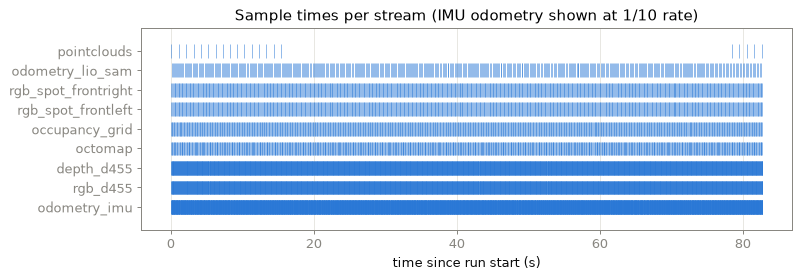

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.2))
rows = ["odometry_imu", "rgb_d455", "depth_d455", "octomap", "occupancy_grid",
        "rgb_spot_frontleft", "rgb_spot_frontright", "odometry_lio_sam", "pointclouds"]
events = [rel[c][::10] if c == "odometry_imu" else rel[c] for c in rows]
ax.eventplot(events, colors=BLUE, linewidths=0.4, linelengths=0.7)
ax.set_yticks(range(len(rows)), rows)
ax.set_xlabel("time since run start (s)")
ax.set_title("Sample times per stream (IMU odometry shown at 1/10 rate)")
ax.grid(axis="y", visible=False)
plt.tight_layout()

hz = {c: (len(rel[c]) - 1) / (rel[c][-1] - rel[c][0]) for c in rows}
print("  ".join(f"{c}: {r:.3g} Hz" for c, r in hz.items()))

## RGB cameras

Three cameras, sampled evenly across the run. The D455 (top row) is upright
color video — the natural input for our frozen DINOv2 encoder. The two Spot
front cameras are **grayscale** and mounted sideways (image content is rotated
~90°); usable, but they would need rotation and gray→RGB replication, and
DINOv2 features on grayscale are off-distribution.

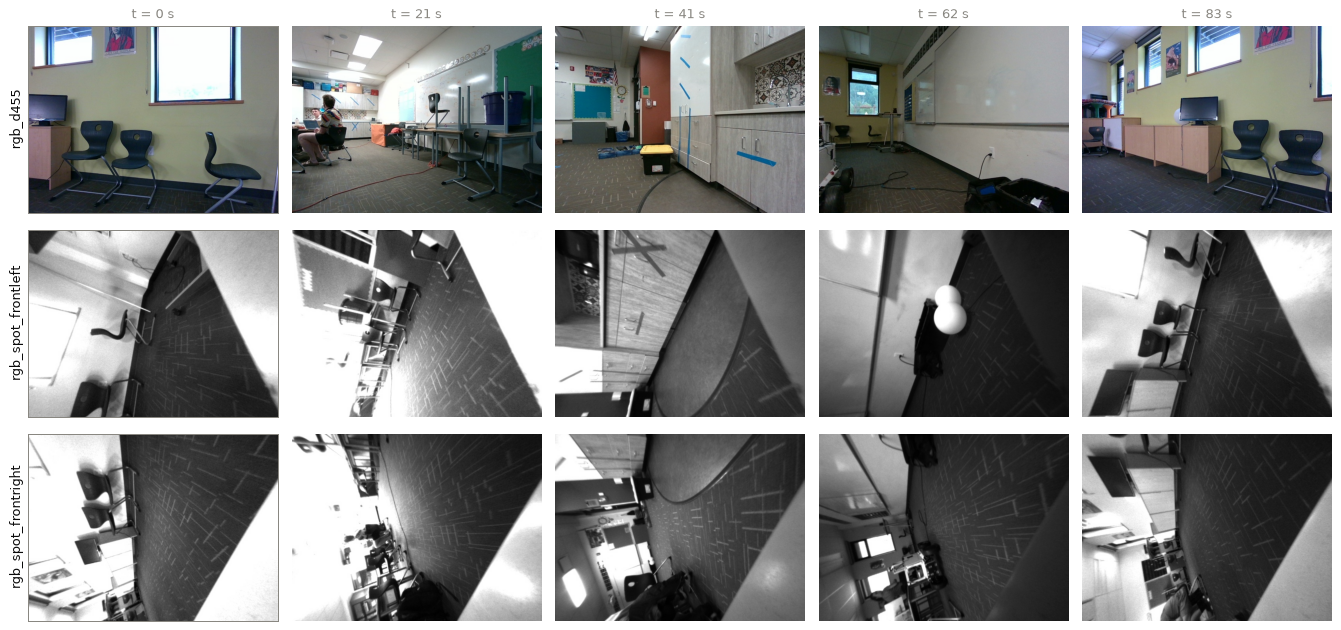

In [3]:
cams = ["rgb_d455", "rgb_spot_frontleft", "rgb_spot_frontright"]
n_show = 5
fig, axes = plt.subplots(len(cams), n_show, figsize=(3 * n_show, 7.2))
for r, cam in enumerate(cams):
    for c, i in enumerate(np.linspace(0, len(streams[cam]) - 1, n_show, dtype=int)):
        ax = axes[r, c]
        ax.imshow(frame(cam, i), cmap="gray")
        ax.set_axis_off()
        if r == 0:
            ax.set_title(f"t = {rel[cam][i]:.0f} s", fontsize=10, color=MUTED)
    axes[r, 0].set_axis_on()
    axes[r, 0].set_ylabel(cam, fontsize=10)
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([]); axes[r, 0].grid(False)
plt.tight_layout()

In [4]:
# Camera intrinsics travel with every row as a JSON string.
for cam in cams:
    ci = json.loads(streams[cam][0]["camera_info"])
    K = np.array(ci["K"]).reshape(3, 3)
    print(f"{cam}: {ci['width']}x{ci['height']}  {ci['distortion_model']}  "
          f"fx={K[0, 0]:.0f} fy={K[1, 1]:.0f} cx={K[0, 2]:.0f} cy={K[1, 2]:.0f}")

rgb_d455: 640x480  plumb_bob  fx=378 fy=378 cx=320 cy=249
rgb_spot_frontleft: 640x480  plumb_bob  fx=257 fy=257 cx=330 cy=244
rgb_spot_frontright: 640x480  plumb_bob  fx=256 fy=256 cx=314 cy=248


## Depth (D455)

`depth_d455` is 640×480 uint16 in millimeters. It pairs with `rgb_d455` by
*time-sorted position* (median offset 0.45 ms — same capture), **not** by raw
row index or `frame_idx` (those disagree between the two configs). Zero pixels
are invalid (no return) and shown in gray.

Text(0.5, 0.98, 'D455 color (top) and aligned depth (bottom)')

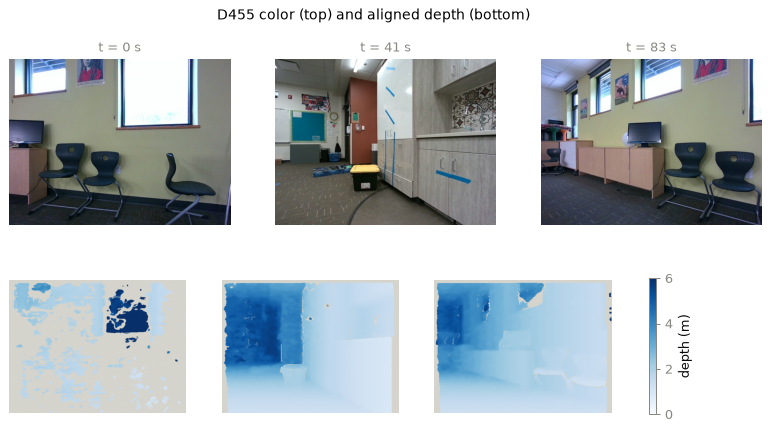

In [5]:
n_pairs = 3
idx = np.linspace(0, len(streams["rgb_d455"]) - 1, n_pairs, dtype=int)
fig, axes = plt.subplots(2, n_pairs, figsize=(3.6 * n_pairs, 5.4))
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#d5d4cd")
for c, i in enumerate(idx):
    axes[0, c].imshow(frame("rgb_d455", i))
    axes[0, c].set_title(f"t = {rel['rgb_d455'][i]:.0f} s", fontsize=10, color=MUTED)
    depth_m = np.asarray(frame("depth_d455", i, col="depth"), dtype=np.float32) / 1000.0
    depth_m[depth_m == 0] = np.nan
    im = axes[1, c].imshow(depth_m, cmap=cmap, vmin=0, vmax=6)
    for ax in axes[:, c]:
        ax.set_axis_off()
fig.colorbar(im, ax=axes[1, :], shrink=0.8, label="depth (m)")
fig.suptitle("D455 color (top) and aligned depth (bottom)", fontsize=11)

## Odometry

Two pose streams with the same schema (`x y z` + quaternion `qx qy qz qw`):
`odometry_lio_sam` (~6 Hz, lidar-SLAM-corrected — use for global position) and
`odometry_imu` (~500 Hz dead reckoning — dense but drifts). Here they agree
closely, so the run has little IMU drift. The robot walks ~31 m of path in one
sweep through the room with two left-turn bursts — and essentially **no right
turns**. Heading (yaw) comes from the quaternion; this plus position is what
we derive actions from below.

path length 24.4 m over 82.5 s


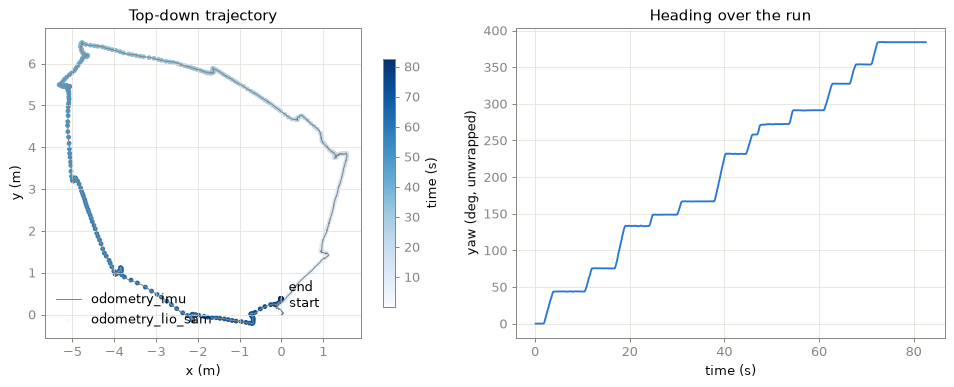

In [6]:
def yaw_of(ds, o):
    qx, qy, qz, qw = (np.asarray(ds[k])[o] for k in ("qx", "qy", "qz", "qw"))
    return np.arctan2(2 * (qw * qz + qx * qy), 1 - 2 * (qy**2 + qz**2))

lio, imu = streams["odometry_lio_sam"], streams["odometry_imu"]
ol, oi = order["odometry_lio_sam"], order["odometry_imu"]
lx, ly = np.asarray(lio["x"])[ol], np.asarray(lio["y"])[ol]
lt, lyaw = rel["odometry_lio_sam"], np.unwrap(yaw_of(lio, ol))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
ax1.plot(np.asarray(imu["x"])[oi], np.asarray(imu["y"])[oi], color=MUTED, lw=0.8,
         label="odometry_imu")
sc = ax1.scatter(lx, ly, c=lt, cmap="Blues", s=8, label="odometry_lio_sam")
ax1.annotate("start", (lx[0], ly[0]), textcoords="offset points", xytext=(6, 6))
ax1.annotate("end", (lx[-1], ly[-1]), textcoords="offset points", xytext=(6, 6))
ax1.set_aspect("equal")
ax1.set_xlabel("x (m)"); ax1.set_ylabel("y (m)")
ax1.set_title("Top-down trajectory")
ax1.legend(loc="lower left", frameon=False)
fig.colorbar(sc, ax=ax1, shrink=0.8, label="time (s)")

ax2.plot(lt, np.degrees(lyaw), color=BLUE, lw=1.5)
ax2.set_xlabel("time (s)"); ax2.set_ylabel("yaw (deg, unwrapped)")
ax2.set_title("Heading over the run")
plt.tight_layout()

seg = np.hypot(np.diff(lx), np.diff(ly))
print(f"path length {seg.sum():.1f} m over {lt[-1] - lt[0]:.1f} s")

## Maps: occupancy grid, octomap, lidar pointclouds

`occupancy_grid` snapshots show the 2D map being built during the run (white =
free, black = occupied, mid-gray = unknown); the repo also ships a final map
under `static/`. `octomap` is the same idea in 3D (911 binary `.bt` snapshots
— parsing needs the `octomap` C++ tooling, skipped here). `pointclouds` are 21
raw Ouster lidar scans.

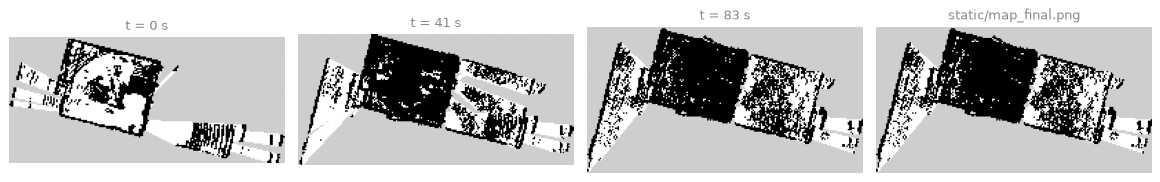

In [7]:
og = streams["occupancy_grid"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, i in zip(axes[:3], np.linspace(0, len(og) - 1, 3, dtype=int)):
    ax.imshow(frame("occupancy_grid", i, col="map_snapshot"), cmap="gray")
    ax.set_title(f"t = {rel['occupancy_grid'][i]:.0f} s", fontsize=10, color=MUTED)
    ax.set_axis_off()
final_map = plt.imread(hf_hub_download(REPO, "static/occupancy_grid/map_final.png", repo_type="dataset"))
axes[3].imshow(final_map, cmap="gray")
axes[3].set_title("static/map_final.png", fontsize=10, color=MUTED)
axes[3].set_axis_off()
plt.tight_layout()

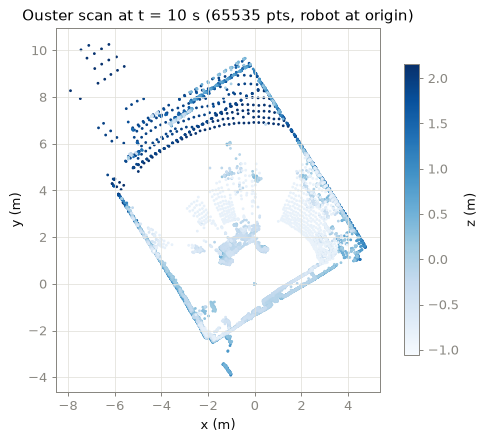

In [8]:
# One lidar scan: ASCII PCD -> (N, 3), top-down view colored by height.
pcd = frame("pointclouds", 10, col="pcd_bytes")
pts = np.loadtxt(pcd.decode().splitlines()[11:], dtype=np.float32)
pts = pts[np.isfinite(pts).all(axis=1)]
keep = pts[np.abs(pts[:, 2]) < 2.5][::5]  # trim outliers, subsample for plotting

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(keep[:, 0], keep[:, 1], c=keep[:, 2], cmap="Blues", s=1.5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title(f"Ouster scan at t = {rel['pointclouds'][10]:.0f} s ({len(pts)} pts, robot at origin)")
fig.colorbar(sc, ax=ax, shrink=0.8, label="z (m)")
plt.tight_layout()

## From sensor streams to JEPA transitions (T12 preview)

Our training format needs `(image_t, action, image_tp1)` with one-hot actions
`(forward, stop, left, right)` — but the dataset records **no commanded
actions**. Until the recorder logs them, we can *derive* pseudo-actions from
odometry:

1. take D455 frames subsampled to ~3 Hz (30 Hz consecutive frames are
   near-duplicates — the `frame_skip` concern from T02),
2. interpolate the LIO-SAM pose at each frame time,
3. per transition compute forward speed and yaw rate,
4. threshold: turning → `left`/`right`, else moving → `forward`, else `stop`.

action counts: {'forward': 126, 'stop': 75, 'left': 46, 'right': 0}


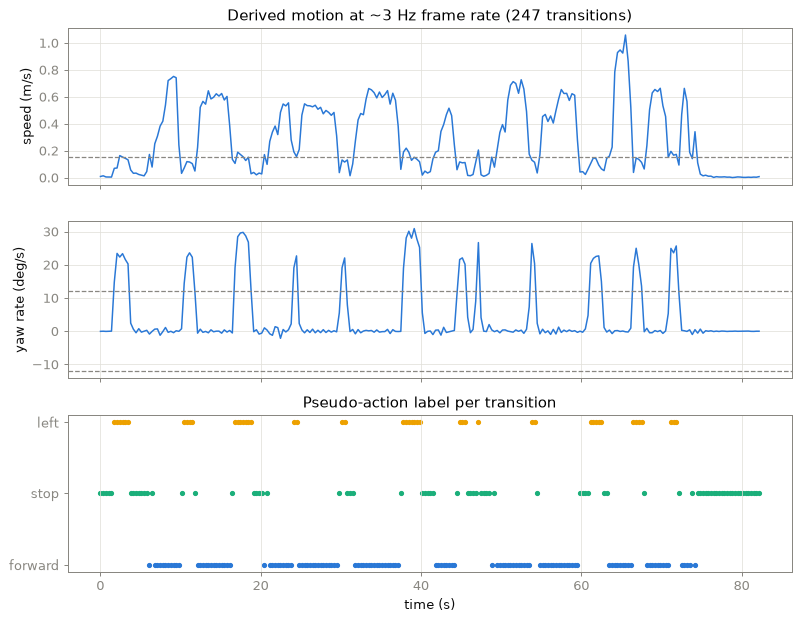

In [9]:
SKIP = 10              # every 10th D455 frame (in time order) -> ~3 Hz
V_TH = 0.15            # m/s: below this, not translating
W_TH = np.radians(12)  # rad/s: above this, turning dominates

tf = rel["rgb_d455"][::SKIP]
fx = np.interp(tf, lt, lx)
fy = np.interp(tf, lt, ly)
fyaw = np.interp(tf, lt, lyaw)

dt = np.diff(tf)
speed = np.hypot(np.diff(fx), np.diff(fy)) / dt
yawrate = np.diff(fyaw) / dt

actions = np.where(yawrate > W_TH, "left",
           np.where(yawrate < -W_TH, "right",
            np.where(speed > V_TH, "forward", "stop")))

ACTION_COLORS = {"forward": BLUE, "stop": AQUA, "left": YELLOW, "right": GREEN}
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
tm = tf[:-1]
ax1.plot(tm, speed, color=BLUE, lw=1.2)
ax1.axhline(V_TH, color=MUTED, lw=1, ls="--")
ax1.set_ylabel("speed (m/s)")
ax1.set_title(f"Derived motion at ~3 Hz frame rate ({len(actions)} transitions)")
ax2.plot(tm, np.degrees(yawrate), color=BLUE, lw=1.2)
for th in (np.degrees(W_TH), -np.degrees(W_TH)):
    ax2.axhline(th, color=MUTED, lw=1, ls="--")
ax2.set_ylabel("yaw rate (deg/s)")
for name, color in ACTION_COLORS.items():
    m = actions == name
    ax3.scatter(tm[m], np.full(m.sum(), name), color=color, s=10)
ax3.set_xlabel("time (s)")
ax3.set_title("Pseudo-action label per transition")
ax3.grid(axis="y", visible=False)
plt.tight_layout()

counts = {a: int((actions == a).sum()) for a in ACTION_COLORS}
print("action counts:", counts)

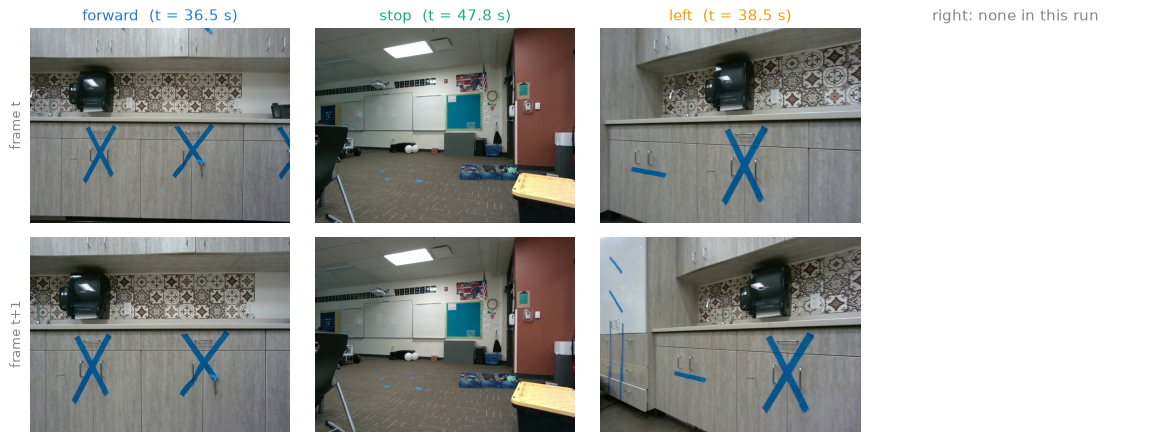

In [10]:
# One example transition (img_t -> img_tp1) per derived action.
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for c, (name, color) in enumerate(ACTION_COLORS.items()):
    axes[0, c].set_axis_off(); axes[1, c].set_axis_off()
    hits = np.flatnonzero(actions == name)
    if len(hits) == 0:
        axes[0, c].set_title(f"{name}: none in this run", color=MUTED)
        continue
    i = int(hits[len(hits) // 2])
    axes[0, c].imshow(frame("rgb_d455", i * SKIP))
    axes[1, c].imshow(frame("rgb_d455", (i + 1) * SKIP))
    axes[0, c].set_title(f"{name}  (t = {tf[i]:.1f} s)", color=color)
axes[0, 0].text(-0.08, 0.5, "frame t", transform=axes[0, 0].transAxes,
                rotation=90, va="center", color=MUTED)
axes[1, 0].text(-0.08, 0.5, "frame t+1", transform=axes[1, 0].transAxes,
                rotation=90, va="center", color=MUTED)
plt.tight_layout()

## Takeaways

- **Camera choice:** `rgb_d455` (upright, color, 30 Hz) is the right JEPA
  input. The Spot front cameras are grayscale, sideways-mounted, and ~9 Hz —
  usable only with rotation + gray→RGB, and off-distribution for DINOv2.
- **Sort by `timestamp_ns` before any temporal use.** Row order is extraction
  order, not time order (the files begin with the end of the run), and differs
  between configs — a converter that pairs RGB/depth or builds transitions by
  row index silently produces garbage.
- **Frame rate:** 30 Hz needs subsampling (~3 Hz here) or the T02
  `frame_skip`; consecutive raw frames are near-identical.
- **No action labels.** Actions must either be logged by the recorder
  (commanded gait — preferred, ask the data collectors) or derived from
  odometry as above. The derived distribution is imbalanced: mostly
  `forward`/`stop`, two `left` bursts, **zero `right`** — this run alone
  cannot teach a model what `right` does.
- **Scale:** one 83 s run ≈ 250 transitions at 3 Hz — same order as the bezier
  toy set, far short of the ≥5k target (T10). More runs are needed either way.
- **Extras for later:** LIO-SAM poses give ground truth for latent probing
  (T14); depth/lidar/maps are unused by the current pipeline but good for
  evaluation.

**Next step (T12):** a small converter script writing
`images/ + transitions_gt.csv` from `rgb_d455` + `odometry_lio_sam`
(time-sorted), with the action-labeling rule above as a stopgap until
commanded actions are recorded — and more runs with deliberate action
coverage, especially right turns.